## Project 2

### See Canvas for assignment dates.

****

## Collaboration policy

This is a **group project** and the team assignments are posted on this Canvas assignment webpage.  **If your name does not appear in a group, you must contact Brent (a private Piazza post) by 11:55 pm, Wednesday, April. 8th.** Please be welcoming and kind to the students in your group (i.e., be a good classmate).

Please be **welcoming and considerate** when forming groups. You are encouraged to reach out to classmates you may not know well and to act as a supportive, inclusive member of the class. If you are unsure about what is or is not allowed, **you must ask for clarification in advance**. Claiming confusion or uncertainty after the fact will not be accepted as an excuse.

**Collaboration is permitted only within your team.** There may be **no collaboration, discussion, or sharing of work between different teams**. All submitted work must be **entirely the product of your own team**.

To ensure fairness for everyone, the **collaboration policy will be strictly enforced**. Any violation may result in **a zero for all students involved**.

In the Markdown cell below, list the full names of all members of your group.


### Team members

1. Yahan Yang
2. Christian Jahnel

****
## AI policy

AI may not be used to generate a coding solution. Your solution must be your own work. If you have any questions about what is or isn't allowed, you must ask. Saying afterwards that you didn't understand or were unsure is not an acceptable excuse.

To ensure fairness for everyone, the **AI policy will be strictly enforced**. Any violation may result in **a zero for all students involved**.



****
## Honor pledge

To acknowledge and understand the **Collaboration and AI policies** outlined above, each team member must enter their Onyen and PID in this markdown cell.

1. ayahan 730649168
2. cjahnel 730665149

****

## Python modules

All the Python modules needed to complete this project are provided to you. 

<span style="background-color: #FFFF00">**No other modules are authorized** and **if other modules are added points will be deducted**.</span>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import math
import warnings
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings('ignore')

****

### Data Clustering using K-means.

The provided dataframe is a $300 \times 2$ matrix of unlabeled data. The columns of the dataframe represent $x$ and $y$ values, and the rows represent data samples.

Tips:
- The introduction to unsupervised learning and k-means slides (see Canvas schedule) may be helpful.
- The matrix decomposition and Principal Component Analysis (PCA) slides (see Canvas schedule) may be helpful.
- Principal component analysis applications.

****

In [2]:
kdf = pd.read_csv("Kmeans.csv" )
kdf

,x,y
0,1.249031,0.995507
1,4.446048,1.860954
2,2.829059,2.506758
3,2.259368,-1.571176
4,2.050265,2.264782
...,...,...
295,1.287713,0.483150
296,2.476145,2.297358
297,3.569654,2.024624
298,4.068340,2.732174


****

**P1A** (2 Points): Unlabeled Data Visualization.

<img src="p1a.png" width="600" style="float: right"/>

Using the **kdf** dataframe, visualize the unlabeled data in a 2D plot.

To receive full credit, your plotting solution must generate a scatter plot that is identical to the one provided.

You may assume:
- All the data is used to generate the scatter plot.
- The color used to generate the plot is blue.
- The plot figure size is **9** inches in width and **7** inches in height.
- The default x-axis and y-axis tick values are used.
- The marker shape is `x`.
- The plot grid is enabled.

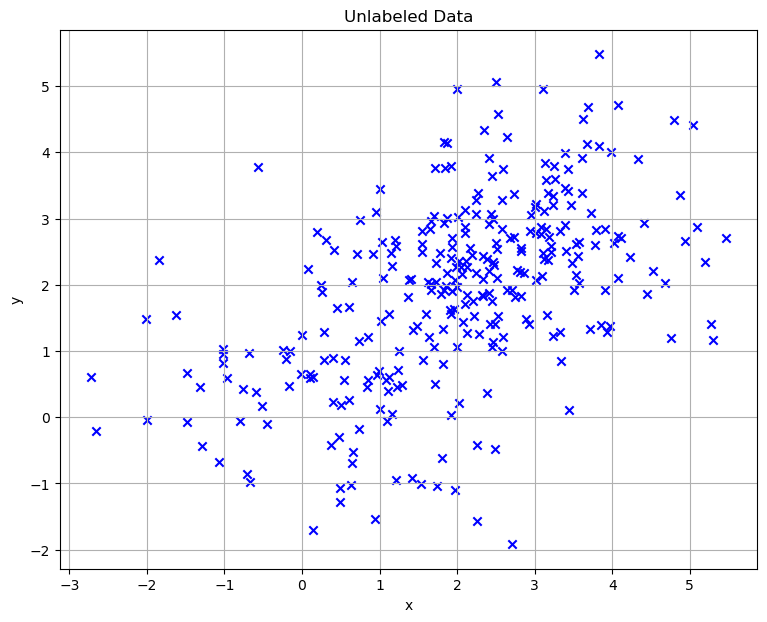

In [3]:
# --------------------------------------
# Add your P1A coding solution below.
# --------------------------------------

plt.figure(figsize=(9,7))
plt.scatter(kdf["x"], kdf["y"], color="blue", marker="x")
plt.title("Unlabeled Data")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show();

****

**P1B** (13 Points): Data Clustering and the K-means Algorithm.

<img src="p1b.png" width="600" style="float: right"/>

Using the **kdf** dataframe, this question will apply the k-means algorithm to group the unlabeled data into cluster sizes $k=1$, $2$, $3$, $4$, $5$, $6$. 

The dotted lines show the path of each cluster's centroid. Specifically, the initial position of the centroid is the ``gray`` diamond, the ``black`` circle indicates the final position, and the dotted line traces the centroid's location at each k-means iteration. 

The stopping criteria for your k-means implementation are whichever comes first:
- when the maximum number of iterations ($N$) is reached, or
- when the absolute difference between the inertia at current iteration ($i$) and the previous iteration ($i-1$) is within a defined tolerance ($\epsilon$).

To receive full credit, your solution should produce plots similar to the reference plots. 

**Notes**:
- Initialize centroids randomly within the data bounds (i.e., each coordinate should lie between the minimum and maximum values of that dimension).
- It is possible that after an iteration, a cluster may have no assigned points (for the reason above). Your implementation must handle this condition by reinitializing the cluster point to a random location.
- <span style="background-color: #FFFF00">Your plots won't be identical because the initial locations of the cluster centroids are randomly generated.</span>.
- The DSML textbook has high-level pseudocode that demonstrates the K-means algorithm (Section 4.6.1). Using the example Python program (Example 4.6) in the DSML textbook is not allowed and will result in an honor code violation. **Do your own work**!
- **If you have questions or are unsure, you and your teammates must ask**.

**Plot Requirements**:
- The plots must be placed in a $3 \times 2$ grid pattern (see reference plots).
- All the data is used to generate the scatter plots.
- The plot figure size is **15** inches in width and **10** inches in height.
- The plot header displays the inertia of the computed clusters.
- The default x-axis and y-axis tick values are used.
- Markers with the **x** shape use default size.
- The size of the **diamond** and **circle** marker shapes is $20$.
- The width of the dotted line is $2.5$.
- The colors used to represent cluster one to six (C1-C6) are `'red', 'blue', 'green', 'orange', 'brown', 'purple'`.
- The opacity value for the markers is $0.4$ (this is not applied to the dashed lines).
- The dashed lines have a `linestyle` of `--`
- The maximum number of iterations (N) is $100$.
- The inertia tolerance ($\epsilon$) is $0.25$. 



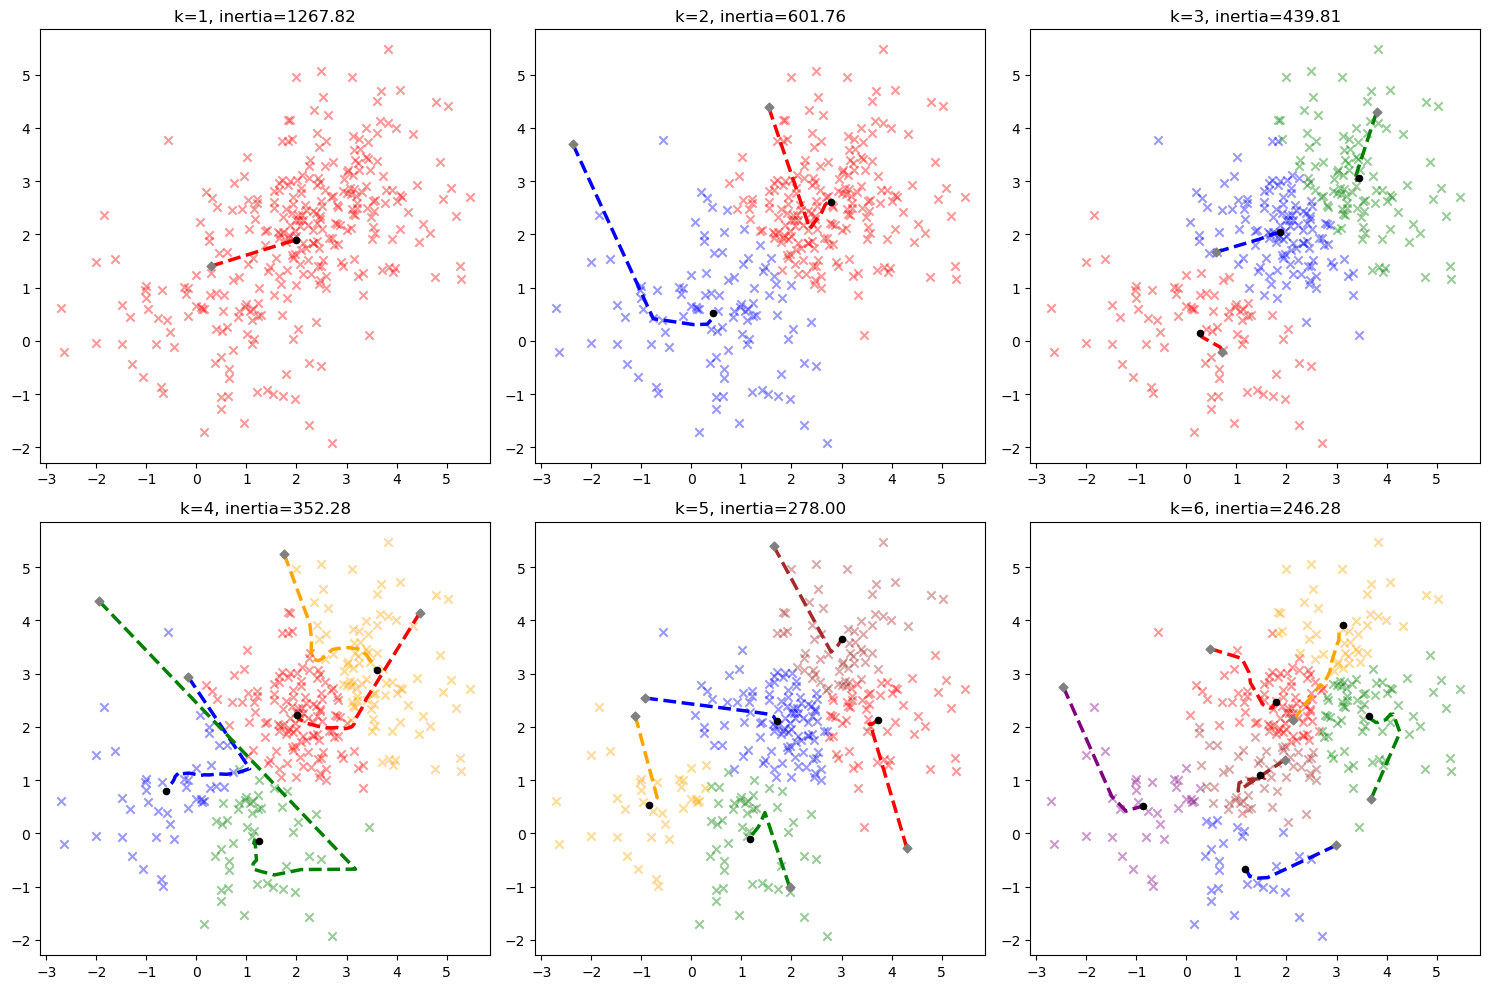

In [8]:
# --------------------------------------
# Add your P1B coding solution below.
# --------------------------------------

colors = ['red','blue','green','orange','brown','purple']
N = 100
epsilon = 0.25
data = kdf.values
cluster = [1,2,3,4,5,6]

x_min, x_max = data[:,0].min(), data[:,0].max()
y_min, y_max = data[:,1].min(), data[:,1].max()

plt.figure(figsize=(15,10))

for idx, K in enumerate(cluster):
    #random initial centers
    c = np.zeros((K, 2))
    for k in range(K):
        c[k,0] = np.random.uniform(x_min,x_max)
        c[k,1] = np.random.uniform(y_min,y_max)
    c_history = [c.copy()]
    labels = np.zeros(len(data), dtype=int)
    prev_inertia = np.inf

    for iteration in range(N):
        for i in range(len(data)):
            distances = []
            for k in range(K):
                d = np.sqrt((data[i,0]-c[k,0])**2+(data[i,1]-c[k,1])**2)
                distances.append(d)
            labels[i] = np.argmin(distances)

        new_c = np.zeros((K, 2))
        for k in range(K):
            cluster_pts = data[labels == k]
            if len(cluster_pts) == 0:
                new_c[k,0] = np.random.uniform(x_min,x_max)
                new_c[k,1] = np.random.uniform(y_min,y_max)
            else:
                new_c[k,0] = cluster_pts[:,0].mean()
                new_c[k,1] = cluster_pts[:,1].mean()
        c = new_c
        c_history.append(c.copy())
        
        inertia = 0
        for i in range(len(data)):
            k = labels[i]
            inertia += (data[i,0]-c[k,0])**2+(data[i,1]-c[k,1])**2
        #check stop
        if abs(inertia-prev_inertia) < epsilon:
            break
        prev_inertia = inertia
        
    plt.subplot(2, 3, idx + 1)
    #scatter
    for k in range(K):
        cluster_pts = data[labels == k]
        plt.scatter(cluster_pts[:, 0], cluster_pts[:, 1], color=colors[k], marker='x', alpha=0.4)
    #path
    history = np.array(c_history)
    for k in range(K):
        path_x = history[:,k,0]
        path_y = history[:,k,1]
        plt.plot(path_x, path_y, linestyle='--', color=colors[k], linewidth=2.5)
        plt.scatter(path_x[0], path_y[0], color='gray', marker='D', s=20, zorder=5)
        plt.scatter(path_x[-1], path_y[-1], color='black', marker='o', s=20, zorder=5)
    plt.title(f'k={K}, inertia={inertia:.2f}')
plt.tight_layout()
plt.show();

****

### Shape Modeling and PCA.

The provided dataframe is a $m \times w$ matrix of face data, where the columns represent shape vectors (e.g., ${\bf f}_i$ is the column vector that represents the i<sup>th</sup> face in the dataset), and the rows represent landmarks on a 2D human face. (<a href="https://ibug.doc.ic.ac.uk/resources/facial-point-annotations/">Reference</a> for this data).

Specifically, the $2n$-dimension column vector ${\bf f}_1=(x_0,y_0,x_1,y_1, \ldots, x_i, y_i, \ldots, x_{n-1}, y_{n-1})$ defines $n=68$ landmark locations on face $1$ (column named **f1**) in the dataset. 

For plotting and visualization, the $2n$ vector can be easily converted to an $n \times 2$ matrix, where each row $(x_i, y_i)$ is a $2D$ point on a face.

Tips:
- The matrix decomposition and Principal Component Analysis (PCA) slides (see Canvas schedule) may be helpful.
- Principal component analysis applications.
- The 1995 published <a href="https://d1wqtxts1xzle7.cloudfront.net/32766354/Active_Shape_Models-Their_Training_and_Application_1995CVIU_-libre.pdf?1391178918=&response-content-disposition=inline%3B+filename%3DActive_Shape_Models_Their_Training_and_A.pdf&Expires=1762267168&Signature=FaJwDlw--eTpPE-~yAuvnkbvNy-PA~9oahRHvG88BR882jnAFkfhWRxpwjt7MUeTPG1uAFm7omi-YWjZ5Ykd6X9SM8oWwZubdiwsG-3PGmzbMdAE7CyDO-q5Q9IACzlG7q4LrNpjLRWEV4Y95KhlQ2bxtQBBkjQgemBytXnoSAOEZ-CHsgvguPmItWyX7OAwupd5CNmSy1wc~EdHARKFG7fHTbeaHSDKsfusEIE3YBmkDluKqUzQfPt-uHK8-zrqlk0kAYxpDzqvghvS~k7ZXRrJPoVnuVkZ8aN0-njGiGHTM7j-kOGS8pO4UaTYPV2A7vYBlMJNuaqr58zqf0vCdg__&Key-Pair-Id=APKAJLOHF5GGSLRBV4ZA">paper</a> (Section 3: PDM) cited 10,909 times (<a href="https://scholar.google.com/citations?user=zhlk0OsAAAAJ&hl=en">reference</a>). 

****

In [9]:
fdf = pd.read_csv("./Faces.csv")
fdf_2 = fdf
fdf.shape

(136, 188)

****

**P2A** (3 Points): Mean Face Visualization.

<img src="p2a.png" width="600" style="float: right"/>

Using the **fdf** dataframe, visualize the mean face vector ($\bar{{\bf x}}$) in a 2D scatter plot.

The mean face vector is 

$$\bar{{\bf x}} = (\bar{x}_0,\bar{y}_0,\bar{x}_1,\bar{y}_1, \ldots \bar{x}_{n-1}, \bar{y}_{n-1}),$$

where $\bar{x}_i$ or $\bar{y}_i$ is the average value for the i<sup>th</sup> landmark across all $m$ face vectors.

To receive full credit, your plotting solution must generate a scatter plot that is identical to the one provided.

**Notes**:
- **If you have questions or are unsure, you and your teammates must ask**.

**Plot Requirements**:
- All the data is used to generate the scatter plot.
- The plot figure size is **8** inches in width and **8** inches in height.
- The color used to generate the plot is ``blue``.
- The default x-axis and y-axis tick values are used.
- The marker shape is `o`.
- The annotation font size is **10**.
- The plot axis is ``equal``.

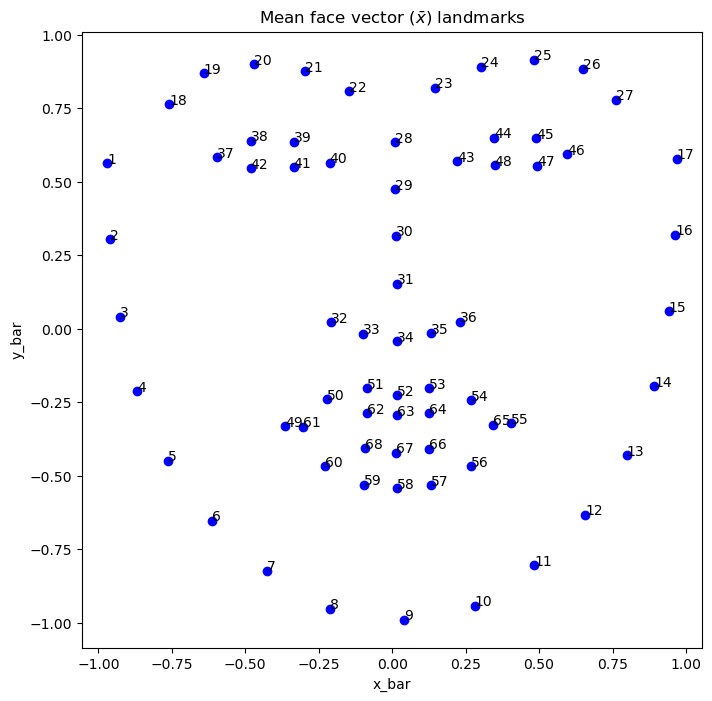

In [10]:
# --------------------------------------
# Add your P2A coding solution below.
# --------------------------------------

x_bar = fdf.mean(axis=1)
x_bar = np.reshape(x_bar.values, (68, 2))
x_bar = pd.DataFrame(x_bar, columns=['x_bar', 'y_bar'])
plt.figure(figsize=(8, 8))
plt.scatter(x_bar['x_bar'], x_bar['y_bar'], c='blue', marker='o')

for idx, xi, yi in x_bar.itertuples():
    plt.annotate(idx + 1,
                xy=(xi, yi), xycoords='data', fontsize=10)

plt.title(r"Mean face vector ($\bar{x}$) landmarks")
plt.axis('equal')
plt.xlabel("x_bar")
plt.ylabel("y_bar")
plt.show();

****

**P2B** (12 Points): PCA and Shape Modeling.

<img src="p2b.png" width="600" style="float: right"/>

Using the **fdf** dataframe and the mean shape vector ($\bar{{\bf x}}$), perform principal component analysis (PCA) and visualize the shape space.

Specifically, a new face vector ($\hat{{\bf x}}$) should be generated by

$$\hat{{\bf x}} = \bar{{\bf x}} + \textnormal{V} {\bf b},$$

where $V$ is the eigenvector matrix and ${\bf b}$ is the shape parameters vector. Compute the eigenvector matrix ($V$) and the eigenvalue matrix ($\Lambda$) by performing an eigen decomposition on the covariance matrix ($\Sigma = V \Lambda V^T$). The covariance matrix can be computed using the equation below.

$$\Sigma = \frac{1}{m-1}  \sum_{i=0}^{m-1}({\bf f}_i - \bar{{\bf x}}) ({\bf f}_i - \bar{{\bf x}})^T$$

The shape parameter $b_i$ is the square root of an eigenvalue $\lambda_i$, and it can be varied between $\pm 3$ standard deviations. As shown in the reference plot, the shape parameter will be varied by **$\pm 3$ and $\pm 1.5$** standard deviations. (Note: $b_1$ corresponds to the largest eigenvalue, i.e., the principal component).

Lastly, as shown in the reference plot, only one shape parameter will be varied at a time. Specifically, the top row varies only $b_1$ (the largest eigenvalue), the middle row only $b_2$ (the second-largest eigenvalue), and the bottom row only $b_3$ (the third-largest eigenvalue). The shape parameters that are not varied will be set to zero in the shape vector. 

To receive full credit, your solution should produce plots identical to the reference plots. 

**Notes**:
- You **must** use Eigen decomposition (SVD is not allowed, and all points will be forfeited if used).
- **If you have questions or are unsure, you and your teammates must ask**.

**Plot Requirements**:
- The plots must be placed in a $3 \times 5$ grid pattern (see reference plots).
- All the data is used to generate the scatter plots.
- The plot figure size is **9** inches in width and **9** inches in height.
- The color used to generate the plot is ``blue``.
- The default x-axis and y-axis tick values are removed (<a href="https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.xticks.html">reference</a>).
- The marker shape is `.` (a dot).
- The default marker size is used.
- The plot uses a tight layout (<a href="https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.tight_layout.html">reference</a>).


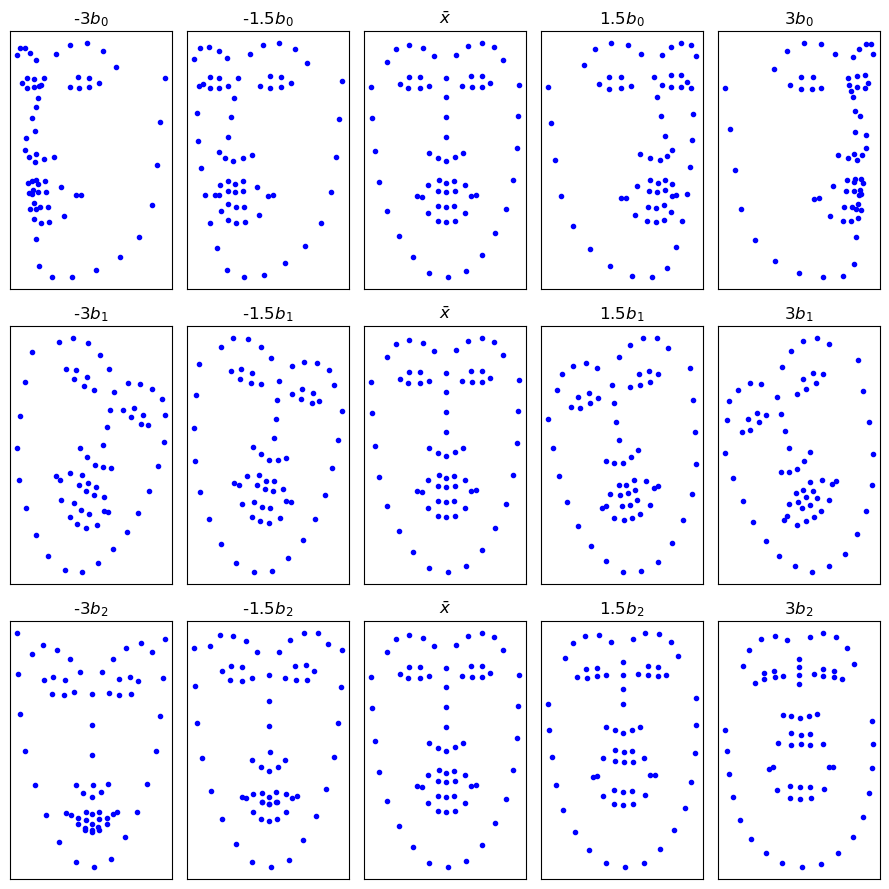

In [11]:
# --------------------------------------
# Add your P2B coding solution below.
# --------------------------------------

f = fdf.values
m = f.shape[1]  # number of samples, which is the 188 faces as columns
x_bar_flat = x_bar.values.reshape(136, 1)  # for broadcasting, I guess
Sigma = 1/(m-1) * (f - x_bar_flat) @ (f - x_bar_flat).T

lambdas, V = np.linalg.eigh(Sigma)  # eigh doesn't invert the first eigenvalue unlike eig
sorted_idx = np.argsort(lambdas)[::-1]  # reverse sort for descending order
lambdas = lambdas[sorted_idx]
V = V[:, sorted_idx]
b = np.sqrt(lambdas)

fig, axs = plt.subplots(3, 5, figsize=(9, 9))

zs = [-3, -1.5, 0, 1.5, 3]

for i in range(3):
    for j in range(5):
        bi = np.zeros((136, 1))
        bi[i] = b[i]
        x_hat = x_bar_flat + V @ (zs[j] * bi)
        x_hat = x_hat.reshape(68, 2)
        axs[i, j].scatter(x_hat[:, 0], x_hat[:, 1], c='blue', marker='.')
        axs[i, j].set_xticks([])
        axs[i, j].set_yticks([])
        axs[i, j].set_title(str(zs[j]) + f"$b_{i}$" if j != 2 else r"$\bar{x}$")

plt.tight_layout();

****

### Shape Modeling and PCA.

The provided dataframe is a $m \times w$ matrix of wine samples. The first column 'Class' represents the type of wine, which is an integer of value `1,2,3`. The other 13 columns represent particular characteristics of each wine sample. (<a href="https://archive.ics.uci.edu/dataset/109/wine">Reference</a> for this data). 


****

In [12]:
wdf = pd.read_csv("./Wine.csv")
wdf

,Class,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


****

**P3** (10 Points): PCA.

<img src="p3.png" width="600" style="float: right"/>

Using the **wdf** dataframe, you are required to perform dimensionality reduction via principal component analysis (PCA) and visualize the resulting space.

Begin by standardizing the dataset, excluding the `Class` with StandardScaler.
Start by computing the eigenvector matrix ($V$) and the eigenvalue matrix ($\Lambda$) by performing an eigen decomposition on the covariance matrix ($\Sigma = V \Lambda V^T$). The covariance matrix can be computed using the equation below.

$$\Sigma = \frac{1}{m-1}  \sum_{i=0}^{m-1}({\bf f}_i - \bar{{\bf x}}) ({\bf f}_i - \bar{{\bf x}})^T$$

The principal components are found from $V$, with corresponding variances derived from the square roots of all the eigenvalues in $\lambda$.

To visualize the data, project it onto the first two principal components (PC1 and PC2), which capture the greatest variance, and plot the result as a scatter plot, coloring each point with its corresponding class. Next, plot the variances of all principal components in descending order of importance.

To receive full credit, your solution should produce plots identical to the reference plots. 

**Notes**:
- You **must** use Eigen decomposition (SVD is not allowed, and all points will be forfeited if used).
- **If you have questions or are unsure, you and your teammates must ask**.

**Plot Requirements**:
- The figure is **10** inches wide and **5** inches tall.
- Class 1 is colored `blue`; Class 2 is colored `orange`; Class 3 is colored `green`. 
- Use alpha of 0.5.
- The default marker is used.
- The marker size is 20.
- The plot on the right figure is colored `blue`.


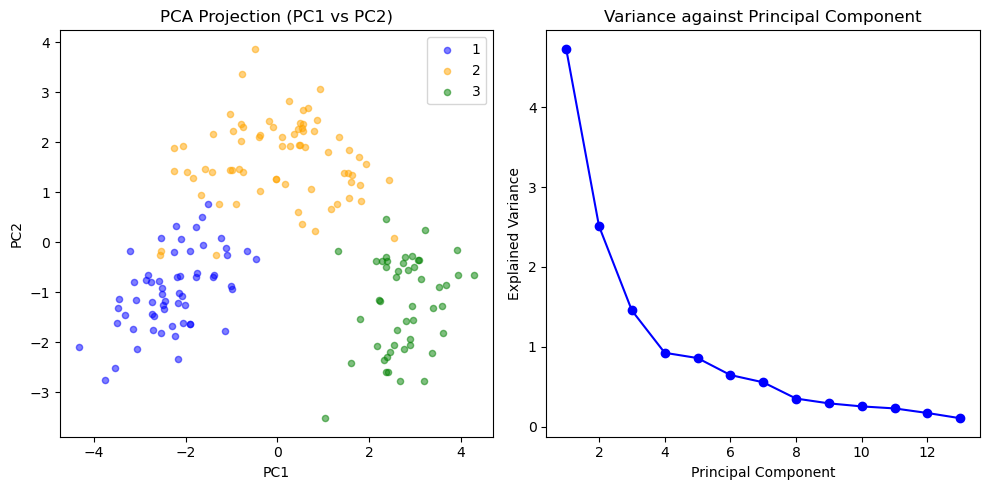

In [13]:
# --------------------------------------
# Add your P3 coding solution below.
# --------------------------------------

y = wdf['Class']
X = wdf.drop(columns=['Class'])
scaler = StandardScaler()
X = scaler.fit_transform(X)

m = X.shape[0]
Sigma = 1/(m-1) * X.T @ X
lambdas, V = np.linalg.eigh(Sigma)
sorted_idx = np.argsort(lambdas)[::-1]
lambdas = lambdas[sorted_idx]
V = V[:, sorted_idx]

W = V[:, :2] # first 2 principal components
Z = X @ W  # projection
Z = pd.DataFrame(Z, columns=['PC1', 'PC2'])
Z = pd.concat([Z, y], axis=1)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

color_map = ('blue', 'orange', 'green')

for i, color in enumerate(color_map):
    subset = Z[Z['Class'] == i+1]
    axs[0].scatter(subset['PC1'], subset['PC2'], c=color, alpha=0.5, s=20, label=(i+1))
axs[0].set_title("PCA Projection (PC1 vs PC2)")
axs[0].set_xlabel("PC1")
axs[0].set_ylabel("PC2")
axs[0].legend()

axs[1].plot(range(1, 14), lambdas, c='blue', marker='o')
axs[1].set_title("Variance against Principal Component")
axs[1].set_xlabel("Principal Component")
axs[1].set_ylabel("Explained Variance")

plt.tight_layout();